In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataverse25/sample_submission-1.csv
/kaggle/input/dataverse25/train.csv
/kaggle/input/dataverse25/test.csv


# The FINAL Report of this code is given here - 
https://omniscient-alder-543.notion.site/Report-2739277a93da80e08a4ffb7d004a8b99


# **Importing required libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, r2_score

# **DATA EDA**

In [3]:
#I am opening and storing the dataframe
train_data=pd.read_csv("/kaggle/input/dataverse25/train.csv")
train_data

,id,City,Area,Building_Type,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,...,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,Last_Inspection_Date,Building_Status,Maintenance_Priority,Energy_Per_SqM,Number_of_Residents,Electricity_Bill,Carbon_Footprint
0,807,Bangalore,Indiranagar,Residential,2002,1,250.000000,530.629672,29.324200,84.244476,...,10,0,5.066212,03-06-2022,Closed,High,126.062569,244,13044.751370,194.218972
1,700,Bangalore,Electronic City,Industrial,2019,5,114.082087,200.000000,65.814354,95.612014,...,3,0,16.720439,06-02-2024,Operational,High,123.863849,37,16774.649620,112.418438
2,299,Bangalore,Malleshwaram,Institutional,1983,7,50.000000,300.841795,12.616114,94.577437,...,9,0,10.964935,14-02-2024,Under Maintenance,Low,181.481442,20,10339.815670,96.279147
3,542,Bangalore,BTM Layout,Institutional,1987,7,50.000000,717.894732,41.233303,88.539227,...,2,0,15.144339,16-08-2023,Operational,High,176.490209,304,13314.465140,98.636968
4,1029,Bangalore,Jayanagar,Residential,1974,8,250.000000,200.000000,36.998686,91.933448,...,5,0,6.755898,15-05-2024,Under Maintenance,Medium,98.860372,354,15890.946360,193.186965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,1044,Bangalore,BTM Layout,Commercial,2017,13,250.000000,200.000000,16.889496,96.136080,...,5,0,8.499914,23-05-2022,Operational,Medium,141.368635,49,14828.987040,192.267603
871,1095,Bangalore,BTM Layout,Commercial,2013,6,50.000000,1104.346639,5.401686,62.055646,...,4,0,17.705763,29-03-2023,Operational,Low,145.964171,326,5191.145924,103.675523
872,1130,Bangalore,Malleshwaram,Commercial,1986,11,192.788337,1500.000000,19.730502,49.788178,...,4,1,72.000000,31-12-2023,Operational,High,166.067861,155,23362.030160,119.206972
873,860,Bangalore,HSR Layout,Industrial,2015,2,224.100389,200.000000,45.220014,95.966973,...,4,0,8.081216,18-11-2021,Closed,High,160.146151,71,9398.009440,176.191137


In [4]:
train_data.info()
# - 21 columns
# - As per 1st looks there are no NULL values that need to be Cleaned.
# - There are 875 Rows
# - The Data types for each column is shown.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           875 non-null    int64  
 1   City                         875 non-null    object 
 2   Area                         875 non-null    object 
 3   Building_Type                875 non-null    object 
 4   Construction_Year            875 non-null    int64  
 5   Number_of_Floors             875 non-null    int64  
 6   Energy_Consumption_Per_SqM   875 non-null    float64
 7   Water_Usage_Per_Building     875 non-null    float64
 8   Waste_Recycled_Percentage    875 non-null    float64
 9   Occupancy_Rate               875 non-null    float64
 10  Indoor_Air_Quality           875 non-null    float64
 11  Smart_Devices_Count          875 non-null    int64  
 12  Green_Certified              875 non-null    int64  
 13  Maintenance_Resoluti

In [5]:
train_data.describe()
# showing values like count, mean, standard deviation, minimum and quartiles for each numerical column.

,id,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,Energy_Per_SqM,Number_of_Residents,Electricity_Bill,Carbon_Footprint
count,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000,875.000000
mean,627.969143,1997.160000,7.097143,107.835489,644.493484,29.551161,77.053848,40.463942,5.237714,0.227429,9.692319,151.491151,252.410286,14917.181279,114.557191
std,363.349014,15.769057,3.799726,72.018162,486.660957,16.639803,15.153647,33.631754,3.270868,0.419411,7.459403,48.271937,142.929515,5085.875908,41.632885
min,0.000000,1970.000000,1.000000,50.000000,200.000000,0.908321,17.600798,0.079244,1.000000,0.000000,5.000417,50.000000,1.000000,2000.000000,30.394136
25%,316.500000,1984.000000,4.000000,50.000000,200.000000,16.083116,67.740527,11.619563,3.000000,0.000000,5.938869,118.121822,128.500000,11364.733425,92.355131
50%,633.000000,1997.000000,7.000000,71.049748,449.186761,27.997150,80.277138,29.759588,5.000000,0.000000,7.441027,151.487807,258.000000,14919.527810,104.877994
75%,938.500000,2011.000000,10.000000,151.094284,1012.806158,40.867279,88.817936,66.036920,7.000000,0.000000,10.516751,181.844107,378.500000,18355.650640,138.083977
max,1249.000000,2023.000000,13.000000,250.000000,1500.000000,80.886835,99.923707,100.000000,19.000000,1.000000,72.000000,286.008458,498.000000,32568.381570,215.473365


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'Construction_Year'}>,
        <Axes: title={'center': 'Number_of_Floors'}>,
        <Axes: title={'center': 'Energy_Consumption_Per_SqM'}>],
       [<Axes: title={'center': 'Water_Usage_Per_Building'}>,
        <Axes: title={'center': 'Waste_Recycled_Percentage'}>,
        <Axes: title={'center': 'Occupancy_Rate'}>,
        <Axes: title={'center': 'Indoor_Air_Quality'}>],
       [<Axes: title={'center': 'Smart_Devices_Count'}>,
        <Axes: title={'center': 'Green_Certified'}>,
        <Axes: title={'center': 'Maintenance_Resolution_Time'}>,
        <Axes: title={'center': 'Energy_Per_SqM'}>],
       [<Axes: title={'center': 'Number_of_Residents'}>,
        <Axes: title={'center': 'Electricity_Bill'}>,
        <Axes: title={'center': 'Carbon_Footprint'}>, <Axes: >]],
      dtype=object)

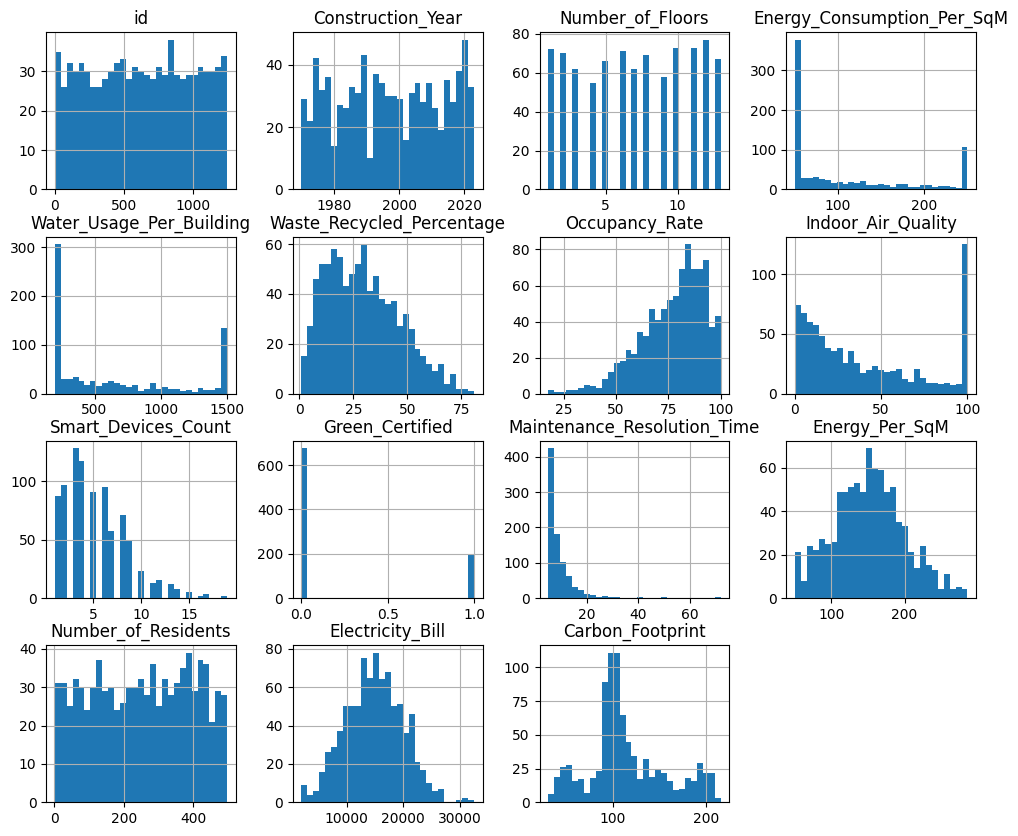

In [6]:
train_data.hist(bins= int(np.sqrt(875)), figsize=(12,10))
# We can observe the outliers of each graph - 

# - In `Occupance_Rate` graph we can see that the buildings in most locations are usually occupied most of the times. It is Left skewed.
# - In `Construction_Year` graph we can see that on average similar number of buildings are built. But there are fluctuations in a few years.
# - In `Energy_Consumption_Per_SqM` graph we can see that there are 2 outliers, one at the end and one at the starting point of the graph. 
#   The graph is slightly RIGHT skewed. The outlier on the right represents a building (or a small number of buildings) with 
#   exceptionally high energy consumption per square meter. The outlier on the left represents a building with exceptionally 
#   low energy consumption.
# - In `Green_Certified` graph we can see that most of the buildings are NOT CERTIFIED. 0 indicates no certification and 1 indicates certification.
# - In the `Maintainance_Resolution_Time` graph we can see that it is EXTREMELY RIGHT skewed. So, most of the issues are resolved very early.

<Axes: xlabel='Construction_Year', ylabel='Energy_Consumption_Per_SqM'>

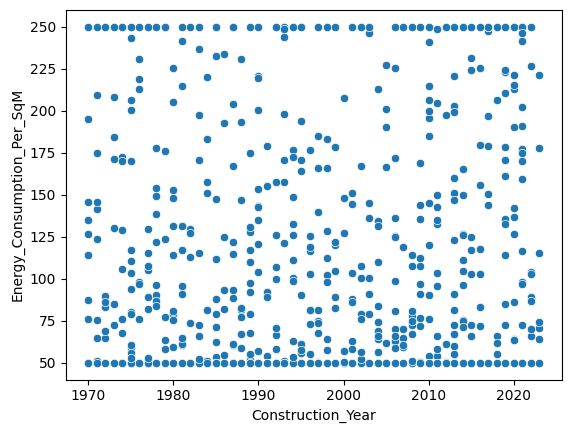

In [7]:
sns.scatterplot(x="Construction_Year", y="Energy_Consumption_Per_SqM", data=train_data)
#No correlation seen

<Axes: xlabel='Number_of_Residents', ylabel='Water_Usage_Per_Building'>

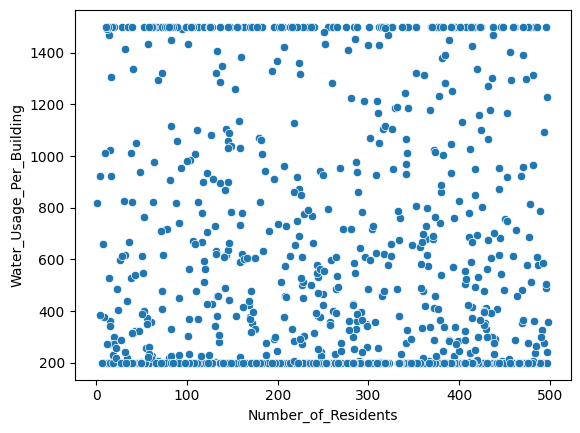

In [8]:
sns.scatterplot(x="Number_of_Residents", y="Water_Usage_Per_Building", data=train_data)
#No correlation seen

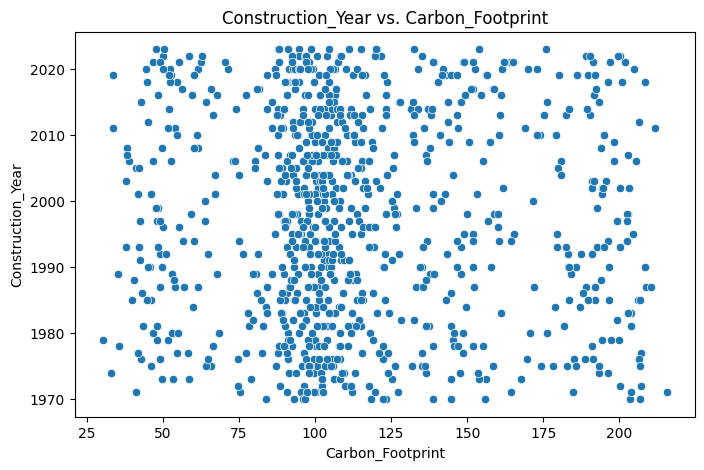

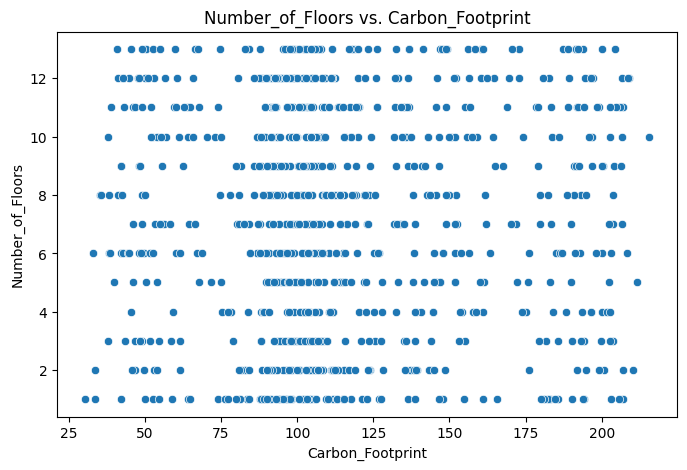

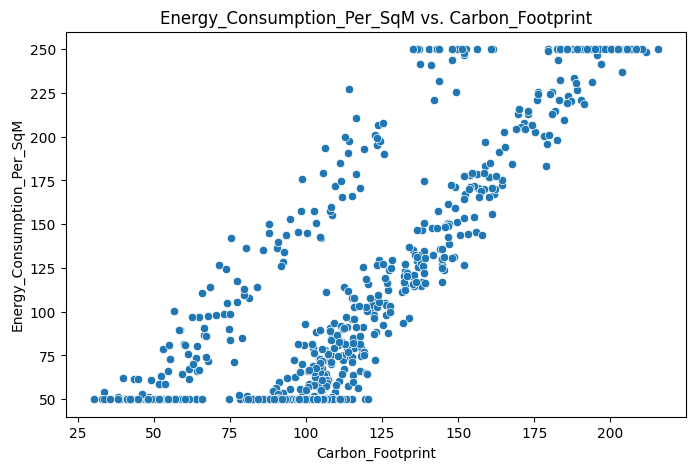

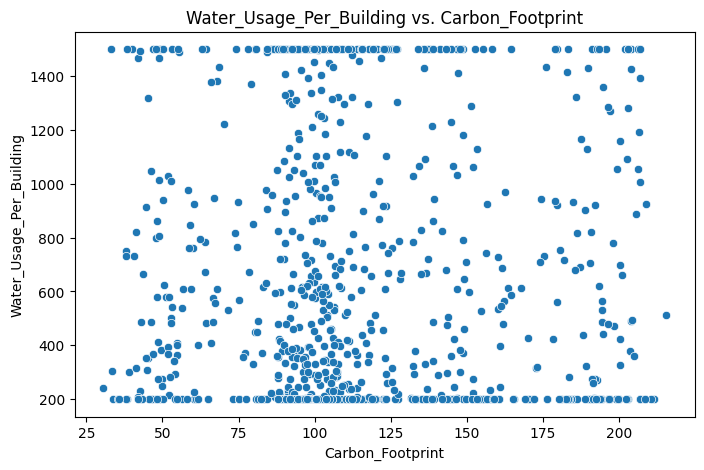

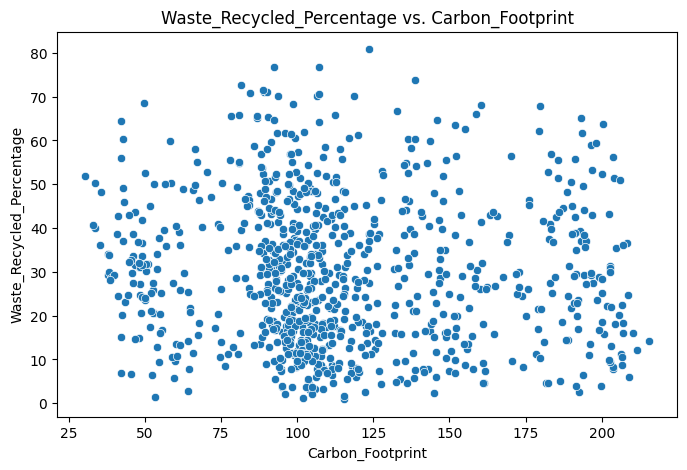

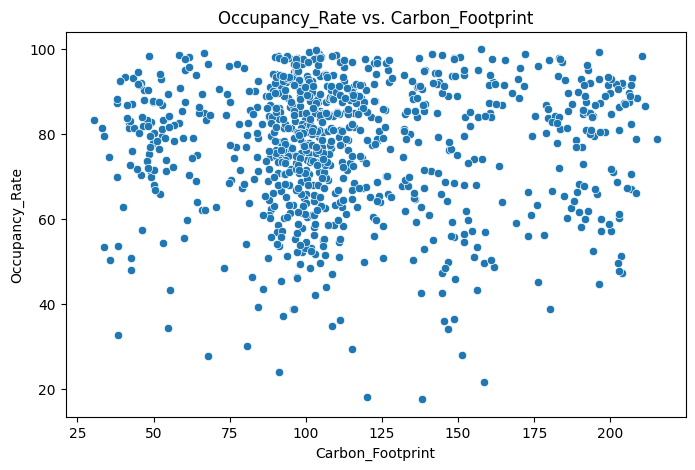

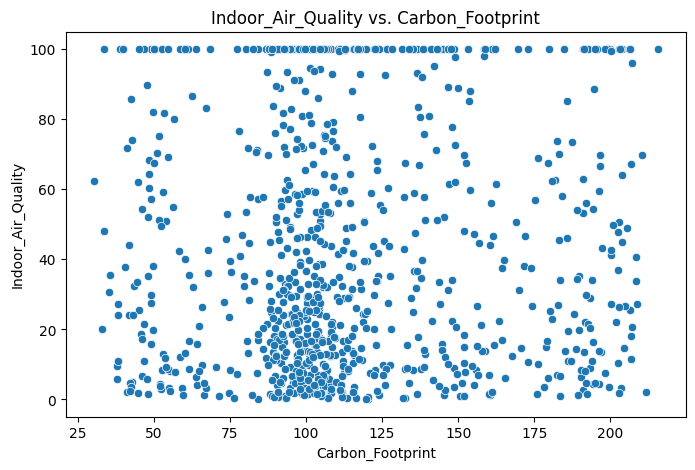

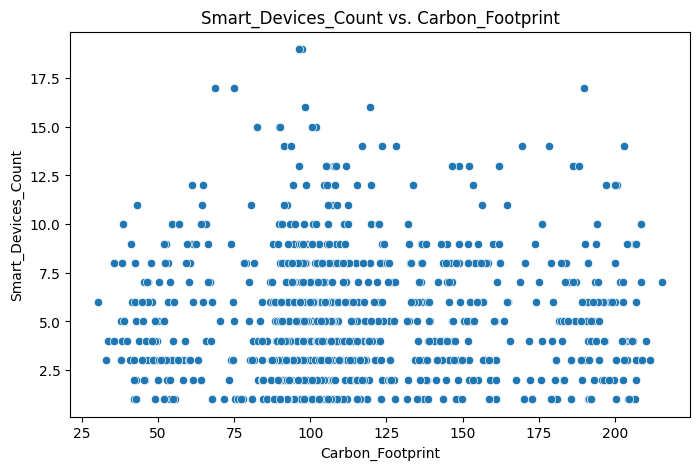

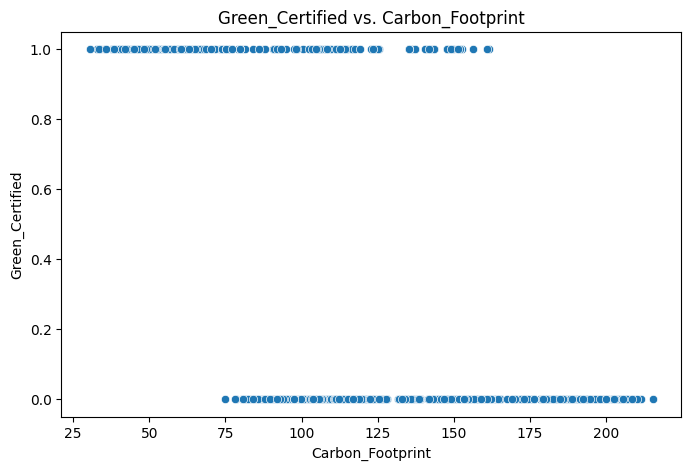

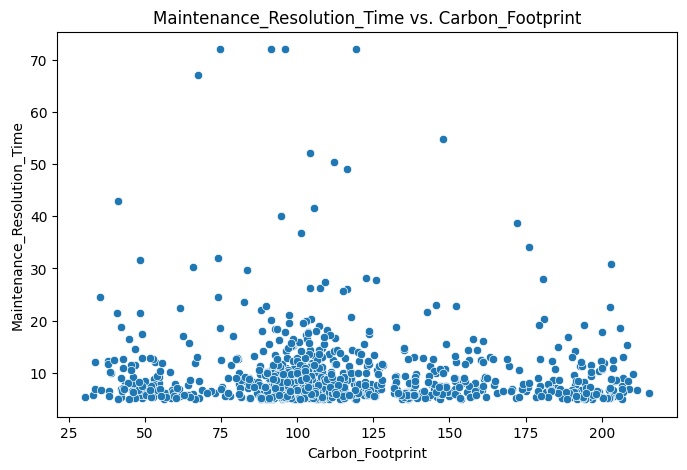

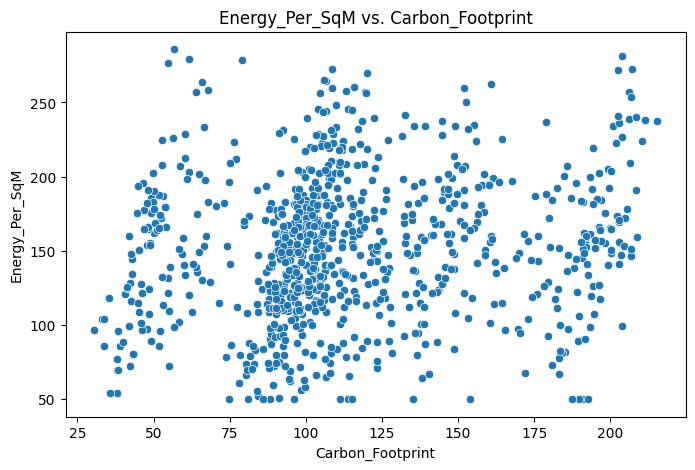

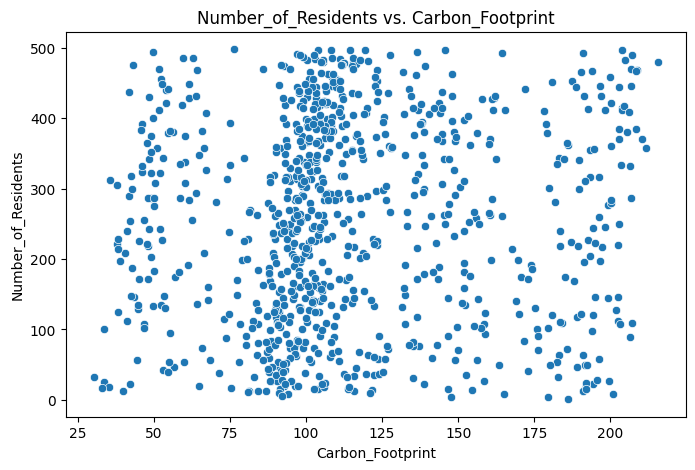

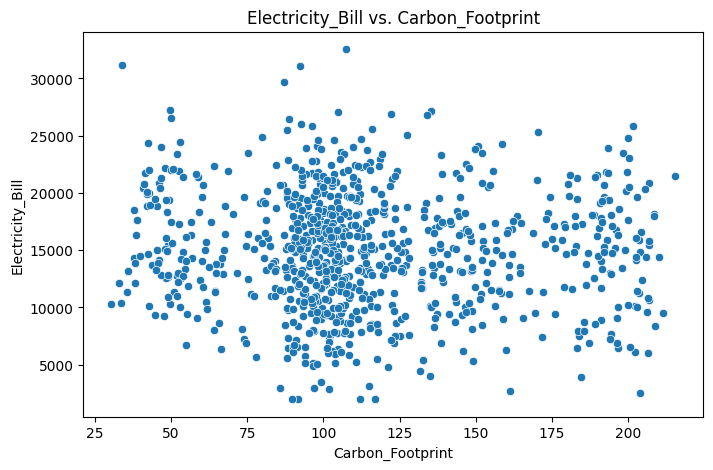

In [9]:
#Analysis of variation of CarbonFootprint with other variables

#Creates a list of columns that have the datatype int64 or float64
numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns

#Removing id and carbon_footprint columns
target_cols = [col for col in numerical_cols if col not in ['Carbon_Footprint', 'id']]

#Main column 
main_col="Carbon_Footprint"

for col in target_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=train_data, x=main_col, y=col)
    plt.title(f'{col} vs. {main_col}')
    

# **Optimizing DataFrame for ML Training**


In [10]:
#Columns Present
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           875 non-null    int64  
 1   City                         875 non-null    object 
 2   Area                         875 non-null    object 
 3   Building_Type                875 non-null    object 
 4   Construction_Year            875 non-null    int64  
 5   Number_of_Floors             875 non-null    int64  
 6   Energy_Consumption_Per_SqM   875 non-null    float64
 7   Water_Usage_Per_Building     875 non-null    float64
 8   Waste_Recycled_Percentage    875 non-null    float64
 9   Occupancy_Rate               875 non-null    float64
 10  Indoor_Air_Quality           875 non-null    float64
 11  Smart_Devices_Count          875 non-null    int64  
 12  Green_Certified              875 non-null    int64  
 13  Maintenance_Resoluti

1. After analyzing the scatterplots of each variable with Carbon Footprint in EDA section as well as checking google, these are the MAJOR drivers of Carbon Footprint -
Energy_Consumption_Per_Sqm: Higher energy consumption directly increases the carbon footprint, as most energy production releases greenhouse gases.

- **`Energy_Consumption_Per_Sqm`**: Higher energy consumption directly increases the carbon footprint, as most energy production releases greenhouse gases.
- **`Smart_Devices_Count`**: A higher count of smart devices can decrease the carbon footprint by optimizing energy use for things like heating and lighting.
- **`Occupancy_Rate`**: A higher occupancy rate typically increases the carbon footprint due to greater energy and resource consumption from more people.
- **`Waste_Recycled_Percentage`**: A higher waste recycling percentage decreases the carbon footprint by reducing landfill emissions and the energy needed to produce new materials.
- **`Building_Type`**: The type of building (e.g., residential, commercial) sets a baseline for energy needs, directly influencing its overall carbon footprint.
- **`Number_of_Residents`**: A higher number of residents directly increases the carbon footprint through greater consumption of electricity, water, and other resources.

In [11]:
train_data["Building_Type"] = train_data["Building_Type"].replace({ "Residential" : 1 ,
                                                                  "Industrial" : 2 ,
                                                                  "Institutional" : 3,
                                                                  "Commercial" : 4})

/tmp/ipykernel_13/258401106.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data["Building_Type"] = train_data["Building_Type"].replace({ "Residential" : 1 ,


In [12]:
# Creating a new dataframe that will contain all the important/required columns
new_df =train_data.copy()
df_cols=train_data.columns
drop_cols=[col for col in df_cols if col not in ["Energy_Consumption_Per_SqM", "Smart_Devices_Count", 
                                                 "Occupancy_Rate", "Waste_Recycled_Percentage", 
                                                 "Carbon_Footprint", "Building_Type", "Number_of_Residents", "Green_Certified" ]]
new_df=new_df.drop(drop_cols, axis=1)
new_df


,Building_Type,Energy_Consumption_Per_SqM,Waste_Recycled_Percentage,Occupancy_Rate,Smart_Devices_Count,Green_Certified,Number_of_Residents,Carbon_Footprint
0,1,250.000000,29.324200,84.244476,10,0,244,194.218972
1,2,114.082087,65.814354,95.612014,3,0,37,112.418438
2,3,50.000000,12.616114,94.577437,9,0,20,96.279147
3,3,50.000000,41.233303,88.539227,2,0,304,98.636968
4,1,250.000000,36.998686,91.933448,5,0,354,193.186965
...,...,...,...,...,...,...,...,...
870,4,250.000000,16.889496,96.136080,5,0,49,192.267603
871,4,50.000000,5.401686,62.055646,4,0,326,103.675523
872,4,192.788337,19.730502,49.788178,4,1,155,119.206972
873,2,224.100389,45.220014,95.966973,4,0,71,176.191137


# **Splitting Data**

In [13]:

x=new_df.iloc[:,:-1]
y=new_df.iloc[:,-1]
x

,Building_Type,Energy_Consumption_Per_SqM,Waste_Recycled_Percentage,Occupancy_Rate,Smart_Devices_Count,Green_Certified,Number_of_Residents
0,1,250.000000,29.324200,84.244476,10,0,244
1,2,114.082087,65.814354,95.612014,3,0,37
2,3,50.000000,12.616114,94.577437,9,0,20
3,3,50.000000,41.233303,88.539227,2,0,304
4,1,250.000000,36.998686,91.933448,5,0,354
...,...,...,...,...,...,...,...
870,4,250.000000,16.889496,96.136080,5,0,49
871,4,50.000000,5.401686,62.055646,4,0,326
872,4,192.788337,19.730502,49.788178,4,1,155
873,2,224.100389,45.220014,95.966973,4,0,71


In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1, random_state=42)

# **Model training**

In [15]:
#Creating a function that provides the report of a model - 
def report(test, pred):
    print("The R2 score of the model is : ", r2_score(test, pred))


In [16]:
#Importing these ML models - 

from sklearn.tree import DecisionTreeRegressor      # Decision Tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  #Random Forest, Gradient Boosting

**Decision Tree**

In [17]:
DT_model= DecisionTreeRegressor()
DT_model.fit(x_train, y_train)
DT_predict= DT_model.predict(x_test)
report(y_test, DT_predict)

The R2 score of the model is :  0.9538370062930789


**Random Forest**

In [18]:
RF_model= RandomForestRegressor()
RF_model.fit(x_train, y_train)
RF_predict= RF_model.predict(x_test)
report(y_test, RF_predict)

The R2 score of the model is :  0.9795459530671782


**Gradient Boosting**

In [19]:
GB_model= GradientBoostingRegressor()
GB_model.fit(x_train, y_train)
GB_predict= GB_model.predict(x_test)
report(y_test, GB_predict)

The R2 score of the model is :  0.9841041233372967


# **We will be using Gradient Boost as it gives the BEST R2 score among all 3**

# **Generating Predictions from test.csv file**

In [20]:
test_data=pd.read_csv("/kaggle/input/dataverse25/test.csv")

In [21]:
#Converting to similar data as in new_df
test_data["Building_Type"] = test_data["Building_Type"].replace({ "Residential" : 1 ,
                                                                  "Industrial" : 2 ,
                                                                  "Institutional" : 3,
                                                                  "Commercial" : 4})
#saving ids which are required while saving
ids=test_data["id"]

/tmp/ipykernel_13/3498510194.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data["Building_Type"] = test_data["Building_Type"].replace({ "Residential" : 1 ,


In [22]:
# Creating a new dataframe that will contain all the important/required columns
new_df =test_data.copy()
df_cols=test_data.columns
drop_cols=[col for col in df_cols if col not in ["Energy_Consumption_Per_SqM", "Smart_Devices_Count", 
                                                 "Occupancy_Rate", "Waste_Recycled_Percentage", "Building_Type", "Number_of_Residents", "Green_Certified" ]]
new_df=new_df.drop(drop_cols, axis=1)
new_df

,Building_Type,Energy_Consumption_Per_SqM,Waste_Recycled_Percentage,Occupancy_Rate,Smart_Devices_Count,Green_Certified,Number_of_Residents
0,1,250.000000,30.936528,52.793795,7,0,410
1,3,250.000000,10.459398,71.176156,9,1,358
2,2,50.000000,17.019110,96.663980,1,1,302
3,2,50.000000,14.824653,38.936660,7,0,148
4,4,50.000000,13.883214,92.992691,2,1,160
...,...,...,...,...,...,...,...
370,4,50.000000,35.968128,93.101556,4,0,116
371,3,121.536270,5.868874,90.707173,2,0,362
372,2,139.764453,53.471944,65.365416,8,1,118
373,2,88.298647,31.807491,93.850749,4,0,18


In [23]:
#Predicting based on test data
x_nt=new_df.iloc[:,:]
GB_predict_new= GB_model.predict(x_nt)

In [24]:
#Creating final dataframe
final_df = pd.DataFrame({"id":ids, "Carbon_Footprint":GB_predict_new })
final_df

,id,Carbon_Footprint
0,680,201.813248
1,1102,156.093964
2,394,51.913195
3,930,98.354222
4,497,49.686048
...,...,...
370,66,90.429614
371,67,139.351284
372,376,86.998390
373,211,106.799308


In [25]:
#Saving Final predictions as csv file - 
final_df.to_csv("karthik_submission.csv", index=False)